In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
'''图片数据集载入'''
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
transform1 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
test_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_splited/test'
testset1 = torchvision.datasets.ImageFolder(root=test_path,transform=transform1)
print(len(testset1))
testloader1 = torch.utils.data.DataLoader(
    testset1, batch_size=128, shuffle=False)

327


In [5]:
'''骨架坐标点数据集载入'''
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/yoga/landmarks/test_landmarks.csv",encoding='gbk')
df.loc[df['体式']=='downdog', '体式编号'] = 0
df.loc[df['体式']=='goddess', '体式编号'] = 1
df.loc[df['体式']=='lowcobra', '体式编号'] = 2
df.loc[df['体式']=='tree', '体式编号'] = 3
df.loc[df['体式']=='warrior2', '体式编号'] = 4
df.drop(["编号", '体式', '标准/不标准'],axis=1, inplace=True)
#df.drop(['体式', '标准/不标准'],axis=1, inplace=True)
dataset_test = df.values
X_test = dataset_test[:,:-1].astype(float)
Y_test = dataset_test[:,-1:].astype(int).squeeze(-1)
X_test, Y_test = torch.Tensor(X_test),torch.LongTensor(Y_test)
#print(X_test)
testset2 = torch.utils.data.TensorDataset(X_test,Y_test)
print(len(testset2))
testloader2 = torch.utils.data.DataLoader(
    testset2, batch_size=128, shuffle=False)

327


In [6]:
import torch.nn as nn
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(p=0.5)
    def forward(self, x):
        out = self.fc1(x)
        out = self.dropout(out)
        out = self.relu(out)
        #print(out.shape)
        out = self.fc2(out)
        return out

In [7]:
def test(net1, net2, we):
    correct = 0
    total = 0
    total_l = [0,0,0,0,0]
    correct_l = [0,0,0,0,0]
    pred_y = torch.tensor([])
    it_testloader2 = iter(testloader2)
    with torch.no_grad():
        for data in testloader1:
            images1, labels = data
            images1, labels = images1.to(device), labels.to(device)
            inputs2, labelss = next(it_testloader2)
            inputs2, labelss = inputs2.to(device), labelss.to(device)
            outputs1 = net1(images1)
            outputs2 = net2(inputs2)
            outputs = outputs1 * we + outputs2
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            #print(predicted, labels)
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(5):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    #print(pred_y)
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中下犬式图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中女神式图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('测试集中低位眼镜蛇式图片的预测精度为：%d%%'%(100 * correct_l[2] / total_l[2]))
    print('测试集中树式图片的预测精度为：%d%%'%(100 * correct_l[3] / total_l[3]))
    print('测试集中战士二式图片的预测精度为：%d%%'%(100 * correct_l[4] / total_l[4]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test, pred_y))

In [8]:
from torchsummary import summary
device = torch.device('cpu')
model1 = torch.load('/content/drive/MyDrive/yoga/models/YogaRegNet_contrast1.pkl', map_location=torch.device('cpu'))
model1.to(device)
model2 = torch.load('/content/drive/MyDrive/yoga/models/YogaRegNet_contrast2.pkl', map_location=torch.device('cpu'))
model2.to(device)


NeuralNet(
  (fc1): Linear(in_features=99, out_features=69, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=69, out_features=5, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [9]:
def test2(net1, net2, we):
    correct = 0
    total = 0
    total_l = [0,0,0,0,0]
    correct_l = [0,0,0,0,0]
    pred_y = torch.tensor([])
    it_testloader2 = iter(testloader2)
    with torch.no_grad():
        for data in testloader1:
            images1, labels = data
            images1, labels = images1.to(device), labels.to(device)
            inputs2, labelss = next(it_testloader2)
            inputs2, labelss = inputs2.to(device), labelss.to(device)
            outputs1 = net1(images1)
            outputs2 = net2(inputs2)
            outputs = outputs1 * we + outputs2
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            #print(predicted, labels)
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(5):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    return (correct / total)

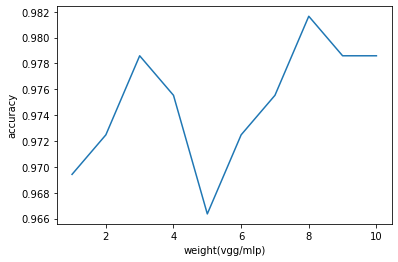

In [10]:
import matplotlib.pyplot as plt
list_ac = []
for we in range(1,11):
  list_ac.append(test2(model1, model2, we))
x_ac = []
for i in range(1,11):
  x_ac.append(i)
plt.plot(x_ac,list_ac)
plt.ylabel("accuracy")
plt.xlabel("weight(vgg/mlp)")
plt.show()

In [11]:
print("测试精度如下：")
test(model1, model2, 3)

测试精度如下：
测试集精度为：98%
测试集中下犬式图片的预测精度为：100%
测试集中女神式图片的预测精度为：96%
测试集中低位眼镜蛇式图片的预测精度为：100%
测试集中树式图片的预测精度为：100%
测试集中战士二式图片的预测精度为：95%
混淆矩阵为：
col_0  0.0  1.0  2.0  3.0  4.0
row_0                         
0       72    0    0    0    0
1        0   57    1    0    1
2        0    0   73    0    0
3        0    0    0   63    0
4        1    2    0    0   57
